---
date: "2026-07-13"
date-modified: last-modified
format:
  html:
    toc: true
---
<!-- CELL BREAK -->

# The Algebra of Measurable Sets

Having defined [measurable sets](measurable-sets.ipynb) via Carathéodory's criterion, we now establish their basic closure properties. Specifically, we will show that the collection of all measurable sets forms an algebra of sets: they are closed under complements and finite unions. 

## 1. Closure Under Complements

**Proposition 1:** If a set $E \subseteq \mathbb{R}$ is measurable, then its complement $E^c$ is also measurable.

::: {.callout-tip collapse="false"}
## Proof of Proposition 1

By the definition of a measurable set, for any test set $A \subseteq \mathbb{R}$, we have:
$$m^*(A) = m^*(A \cap E) + m^*(A \cap E^c)$$
Since $(E^c)^c = E$, we can rewrite this exact equation as:
$$m^*(A) = m^*(A \cap (E^c)^c) + m^*(A \cap E^c)$$
Because addition is commutative, this perfectly matches the Carathéodory criterion for the set $E^c$. Therefore, $E^c$ is measurable. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Symmetry of the Criterion
Carathéodory's definition inherently treats a set and its complement symmetrically. If a boundary is "clean" enough to perfectly slice a test set $A$ from the perspective of the inside ($E$), it is equally clean from the perspective of the outside ($E^c$).
:::

<!-- CELL BREAK -->

## 2. Closure Under Finite Unions

To show that measurable sets form an algebra, we must show that the union of finitely many measurable sets is measurable. By mathematical induction, it suffices to prove this for the case of two sets ($n=2$).

**Proposition 2:** If $E_1$ and $E_2$ are measurable sets, then $E_1 \cup E_2$ is a measurable set.

Before jumping into the proof, let's visualize the intersections. When a test set $A$ interacts with $E_1$ and $E_2$, it gets partitioned into several pieces.

<!-- CODE CELL -->

::: {.callout-tip collapse="false"}

In [1]:
import warnings
warnings.filterwarnings('ignore')

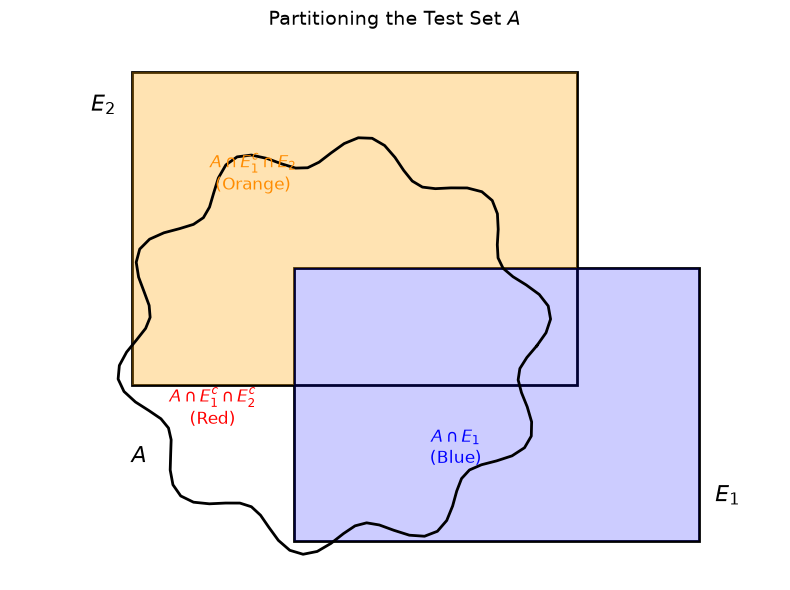

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8, 6))

# A is a wavy blob, we'll approximate with an ellipse for simplicity, but add a wavy boundary
theta = np.linspace(0, 2*np.pi, 100)
r = 2.5 + 0.2 * np.sin(10 * theta)
x_A = 4 + r * np.cos(theta)
y_A = 3 + r * np.sin(theta)
ax.plot(x_A, y_A, color='black', lw=2)
ax.fill(x_A, y_A, color='none', hatch='//', edgecolor='gray', alpha=0.3)
ax.text(1.5, 1.5, '$A$', fontsize=16, fontweight='bold')

# E1 (Right rectangle)
rect_E1 = Rectangle((3.5, 0.5), 5, 3.5, facecolor='none', edgecolor='black', lw=2)
ax.add_patch(rect_E1)
ax.text(8.7, 1, '$E_1$', fontsize=16)

# E2 (Top rectangle)
rect_E2 = Rectangle((1.5, 2.5), 5.5, 4, facecolor='none', edgecolor='black', lw=2)
ax.add_patch(rect_E2)
ax.text(1, 6, '$E_2$', fontsize=16)

# Coloring regions conceptually (overlaying semi-transparent patches)
# 1. A \cap E1 (Blue)
rect_E1_fill = Rectangle((3.5, 0.5), 5, 3.5, facecolor='blue', alpha=0.2)
ax.add_patch(rect_E1_fill)
ax.text(5.5, 1.5, '$A \cap E_1$\n(Blue)', color='blue', fontsize=12, ha='center')

# 2. A \cap E1^c \cap E2 (Orange)
# This is inside E2 but strictly outside E1
rect_E2_diff = Rectangle((1.5, 4), 5.5, 2.5, facecolor='orange', alpha=0.3)
ax.add_patch(rect_E2_diff)
rect_E2_diff2 = Rectangle((1.5, 2.5), 2, 1.5, facecolor='orange', alpha=0.3)
ax.add_patch(rect_E2_diff2)
ax.text(3, 5, '$A \cap E_1^c \cap E_2$\n(Orange)', color='darkorange', fontsize=12, ha='center')

# 3. A \cap E1^c \cap E2^c (Red)
# This is outside both E1 and E2
ax.text(2.5, 2, '$A \cap E_1^c \cap E_2^c$\n(Red)', color='red', fontsize=12, ha='center')

ax.set_xlim(0, 9.5)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_title("Partitioning the Test Set $A$", fontsize=14)

plt.tight_layout()
plt.show()


## Proof of Proposition 2

Let $A \subseteq \mathbb{R}$ be an arbitrary test set. We want to show that $E_1 \cup E_2$ satisfies Carathéodory's criterion, which simplifies to showing the following inequality:

$$m^*(A) \ge m^*(A \cap (E_1 \cup E_2)) + m^*(A \cap (E_1 \cup E_2)^c)$$

**Step 1: Exploit the measurability of $E_1$**
Since $E_1$ is measurable, it cleanly slices $A$:

$$m^*(A) = m^*(A \cap E_1) + m^*(A \cap E_1^c)$$

**Step 2: Exploit the measurability of $E_2$ on the remainder**
Since $E_2$ is also measurable, it must cleanly slice any test set. We choose to use the "outside" portion, $A \cap E_1^c$, as our new test set:

$$m^*(A \cap E_1^c) = m^*(A \cap E_1^c \cap E_2) + m^*(A \cap E_1^c \cap E_2^c)$$

**Step 3: Combine and re-associate**
Substitute the result of Step 2 back into the equation from Step 1:

$$m^*(A) = \underbrace{m^*(A \cap E_1)}_{\text{Blue}} + \underbrace{m^*(A \cap E_1^c \cap E_2)}_{\text{Orange}} + \underbrace{m^*(A \cap E_1^c \cap E_2^c)}_{\text{Red}}$$

Now, observe two set-theoretic facts:

1. By [De Morgan's Laws](pre-logic.ipynb#de-morgans-laws), the "Red" set is exactly the portion of $A$ outside the union:
$$A \cap E_1^c \cap E_2^c = A \cap (E_1 \cup E_2)^c$$


2. The union of the "Blue" and "Orange" sets makes up the portion of $A$ inside the union:
$$(A \cap E_1) \cup (A \cap E_1^c \cap E_2) = A \cap (E_1 \cup E_2)$$



By the [subadditivity](lebesgue-outer-measure.ipynb#further-properties-translation-invariance-and-subadditivity) of the outer measure $m^*$, we know that the measure of a union is less than or equal to the sum of the measures of its parts:

$$m^*(A \cap (E_1 \cup E_2)) \le m^*(A \cap E_1) + m^*(A \cap E_1^c \cap E_2)$$

**Step 4: Final Inequality**
Using the subadditivity inequality to replace the first two terms in our expression for $m^*(A)$ yields:

$$m^*(A) \ge m^*(A \cap (E_1 \cup E_2)) + m^*(A \cap (E_1 \cup E_2)^c)$$

This establishes the required condition, proving that $E_1 \cup E_2$ is measurable. $\blacksquare$
:::